In [1]:
import feast
import numpy as np
import os
from loguru import logger
import dagshub
import mlflow
import time
import joblib
from datetime import datetime
import uuid
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from feast import (
    FeatureStore,
    Entity,
    FeatureService,
    FeatureView,
    Field,
    FileSource
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from feast.types import Float32, Float64, Int64, String

import reescalador

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import (GridSearchCV,
                                     RandomizedSearchCV,
                                     train_test_split)
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (classification_report,
                            confusion_matrix,
                            ConfusionMatrixDisplay)
import lightgbm as lgbm
from xgboost import XGBClassifier, plot_importance
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier


dagshub.init(repo_owner='Marquinhos9873', repo_name='mle3', mlflow=True)




<frozen importlib._bootstrap>:530: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


OSError: libgomp.so.1: cannot open shared object file: No such file or directory

In [3]:
Stresslevel =  pd.read_csv("../data/Stress_Dataset.csv")
Stress = pd.read_csv('../data/StressLevelDataset.csv')

In [4]:
Stresslevel['Which type of stress do you primarily experience?'].unique()
Stresslevel.insert(0, 'Id', range(1, len(Stresslevel) + 1))

In [5]:
Stresslevel['Which type of stress do you primarily experience?'] = Stresslevel['Which type of stress do you primarily experience?'].replace({
    'Eustress (Positive Stress) - Stress that motivates and enhances performance.': 2,
    'No Stress - Currently experiencing minimal to no stress.': 1,
    'Distress (Negative Stress) - Stress that causes anxiety and impairs well-being.': 0
})

/tmp/ipykernel_1092/3091548565.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Stresslevel['Which type of stress do you primarily experience?'] = Stresslevel['Which type of stress do you primarily experience?'].replace({


In [6]:
Stresslevel['Which type of stress do you primarily experience?'] = Stresslevel['Which type of stress do you primarily experience?'].astype(int)
Stresslevel

,Id,Gender,Age,Have you recently experienced stress in your life?,Have you noticed a rapid heartbeat or palpitations?,Have you been dealing with anxiety or tension recently?,Do you face any sleep problems or difficulties falling asleep?,Have you been dealing with anxiety or tension recently?.1,Have you been getting headaches more often than usual?,Do you get irritated easily?,...,Are you facing any difficulties with your professors or instructors?,Is your working environment unpleasant or stressful?,Do you struggle to find time for relaxation and leisure activities?,Is your hostel or home environment causing you difficulties?,Do you lack confidence in your academic performance?,Do you lack confidence in your choice of academic subjects?,Academic and extracurricular activities conflicting for you?,Do you attend classes regularly?,Have you gained/lost weight?,Which type of stress do you primarily experience?
0,1,0,20,3,4,2,5,1,2,1,...,3,1,4,1,2,1,3,1,2,2
1,2,0,20,2,3,2,1,1,1,1,...,3,2,1,1,3,2,1,4,2,2
2,3,0,20,5,4,2,2,1,3,4,...,2,2,2,1,4,1,1,2,1,2
3,4,1,20,3,4,3,2,2,3,4,...,1,1,2,1,2,1,1,5,3,2
4,5,0,20,3,3,3,2,2,4,4,...,2,3,1,2,2,4,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
838,839,0,21,3,4,2,3,5,1,5,...,2,3,3,3,4,1,2,2,2,2
839,840,1,19,3,2,1,2,2,1,2,...,1,1,1,3,2,1,2,3,1,1
840,841,1,19,4,4,3,4,3,2,2,...,2,2,2,2,3,1,4,5,3,2
841,842,0,20,5,4,3,4,3,4,4,...,2,2,1,4,3,5,4,5,1,2


#### Prepare Data

In [7]:
df = Stresslevel
y = df["Which type of stress do you primarily experience?"]
X = df.drop(columns=["Which type of stress do you primarily experience?"])

# Crear promedio de síntomas (todas las preguntas, menos Gender y Age)
symptom_cols = [column for column in X.columns if column not in ["Gender", "Age"]]

#Posible factor psiquis
psiquis_factor = [column for column in X.columns if column in ["Have you recently experienced stress in your life?",
                                                                "Have you been dealing with anxiety or tension recently?",
                                                                "Do you get irritated easily?",
                                                                "Do you have trouble concentrating on your academic tasks?",
                                                               "Do you lack confidence in your academic performance?",
                                                              ]]

#Posible factor biológico
biological_factor = [column for column in X.columns if column in ["Have you noticed a rapid heartbeat or palpitations?",
                                                                  "Do you face any sleep problems or difficulties falling asleep?",
                                                                  "Have you been getting headaches more often than usual?",
                                                                  "Have you gained/lost weight?"                                                                 
                                                                 ]]

#posible factor personal
persona_factor = [column for column in X.columns if column in ["Are you facing any difficulties with your professors or instructors?",
                                                               "Is your working environment unpleasant or stressful?",
                                                               "Do you struggle to find time for relaxation and leisure activities?",
                                                               "Is your hostel or home environment causing you difficulties?",
                                                               "Academic and extracurricular activities conflicting for you?",
                                                               "Do you attend classes regularly?"
                                                              ]]



X["symptom_mean"] = X[symptom_cols].mean(axis = 1)

cols_copy = [column for column in X.columns if column not in ["Id"]]


reducing_data = X.drop(cols_copy, axis = 'columns')

reducing_data["psicological_feature"] = X[psiquis_factor].mean(axis = 1)
reducing_data["biological_feature"] = X[biological_factor].mean(axis = 1)
reducing_data["personal_feature"] = X[persona_factor].mean(axis = 1)

reducing_data

,Id,psicological_feature,biological_feature,personal_feature
0,1,2.0,3.25,2.166667
1,2,2.4,1.75,2.000000
2,3,3.4,2.50,1.666667
3,4,3.0,3.00,1.833333
4,5,3.2,2.75,2.000000
...,...,...,...,...
838,839,3.6,2.50,2.500000
839,840,2.2,1.50,1.833333
840,841,3.0,3.25,2.833333
841,842,3.8,3.25,3.000000


In [8]:
reducing_data.rename(columns={"Id": "Id_user_data"}, inplace=True)

In [9]:
reducing_data

,Id_user_data,psicological_feature,biological_feature,personal_feature
0,1,2.0,3.25,2.166667
1,2,2.4,1.75,2.000000
2,3,3.4,2.50,1.666667
3,4,3.0,3.00,1.833333
4,5,3.2,2.75,2.000000
...,...,...,...,...
838,839,3.6,2.50,2.500000
839,840,2.2,1.50,1.833333
840,841,3.0,3.25,2.833333
841,842,3.8,3.25,3.000000


#### FEATURE STORE

In [10]:
class Feast_use():
    def __init__(self, filepath, external_data=None):
        self.filepath = filepath
        self.feature_table = None
        self.external_data = external_data

        
    def table_creator(self, feature_table=None, external_data=None):

       
        if feature_table is None or feature_table.empty:
            feature_table = pd.DataFrame()
        
        self.feature_table = feature_table

        
        self.feature_table['UId'] = [str(uuid.uuid4()) for _ in range(self.feature_table.shape[0])]
        self.feature_table["created"] = [datetime.now() for _ in range(self.feature_table.shape[0])]
        logger.info(f"Feature Table creada -> {datetime.now()}")

       
        if external_data is not None:
            self.feature_table = pd.concat(
                [
                    self.feature_table.reset_index(drop=True),
                    external_data.reset_index(drop=True)
                ],
                axis=1
            )

        return self.feature_table


    def write_feature_table(self, filepath: str) -> None:
        if self.feature_table is not None and not self.feature_table.empty:
            self.feature_table.to_parquet(f"{filepath}.parquet", index=False)
            self.feature_table.to_csv(f"{filepath}.csv", index=False)
        else:
            raise Exception("La feature table no ha sido creada.")




In [11]:
f = Feast_use(filepath= '/home/marcoloq/mle2/Feature_Store_3/valued_pup/feature_repo')
feature_table_new = f.table_creator(external_data=reducing_data)
logger.info("Guardando feature table")
f.write_feature_table(filepath='/home/marcoloq/mle2/Feature_Store_3/valued_pup/feature_repo')

2025-11-22 02:15:16.120 | INFO     | __main__:table_creator:19 - Feature Table creada -> 2025-11-22 02:15:16.120597
2025-11-22 02:15:16.123 | INFO     | __main__:<module>:3 - Guardando feature table


#### Set tracking // Params

In [12]:
params={"Decision Tree": {
                        "criterion": ['gini','log_loss'],
                        "max_depth": [0, 10, 12, 16],
                        "min_samples_split": [2, 3, 4, 5]
                    },
    
                     "Random Forest":{
                        "n_estimators" : [110 , 115, 125, 130],
                        "criterion" : ['gini' ,'log_loss', 'entropy'],
                        "max_depth" : [None, 5, 7 , 8]
                    },
    
                    "Gradient Boosting": {
                        "n_estimators" : [110 , 115, 125, 130],
                        "max_depth" : [None, 5, 7 , 8],
                        "learning_rate": [0.0045 , 0.01, 0.05, 0.10],
                        "min_samples_split": [2, 3, 4, 5],
                    },
                    "XGBClassifier":{
                        'learning_rate':[0.0045 , 0.01, 0.05, 0.10],
                        'max_depth': [5, 6, 7],
                        'n_estimators': [256, 128, 64, 12],
                        'tree_method': ['auto', 'approx']
                    },
    
                    "CatBoosting Classifier":{
                        'iterations': [200, 400, 800],
                        'learning_rate': [0.001, 0.01, 0.05, 0.1],
                        'depth': [3, 4, 6, 8, 10],
                        'l2_leaf_reg': [1, 3, 5, 7, 9],
                        'bootstrap_type': ['Bayesian', 'Bernoulli', 'MVS']
                    }
                    
                }

In [13]:
SAVE_DIR = "/home/marcoloq/mle2/data/model_metrics_local_pureba_1/"
os.makedirs(SAVE_DIR, exist_ok=True)


In [14]:
xgb = XGBClassifier(device= 'cuda', verbosity = 1)

In [15]:
kitty = CatBoostClassifier(task_type = 'GPU', early_stopping_rounds = 100)

In [16]:
Forest = RandomForestClassifier(verbose = 1)

In [17]:
Grades = GradientBoostingClassifier(verbose = 1) 

In [18]:
Ada = AdaBoostClassifier()

In [31]:
machine = SVC(probability=True)

In [ ]:
lighty = LGBM

#### Revisión

In [20]:
X.columns

Index(['Id', 'Gender', 'Age',
       'Have you recently experienced stress in your life?',
       'Have you noticed a rapid heartbeat or palpitations?',
       'Have you been dealing with anxiety or tension recently?',
       'Do you face any sleep problems or difficulties falling asleep?',
       'Have you been dealing with anxiety or tension recently?.1',
       'Have you been getting headaches more often than usual?',
       'Do you get irritated easily?',
       'Do you have trouble concentrating on your academic tasks?',
       'Have you been feeling sadness or low mood?',
       'Have you been experiencing any illness or health issues?',
       'Do you often feel lonely or isolated?',
       'Do you feel overwhelmed with your academic workload?',
       'Are you in competition with your peers, and does it affect you?',
       'Do you find that your relationship often causes you stress?',
       'Are you facing any difficulties with your professors or instructors?',
       'Is you

In [21]:
X = X.drop(columns=['Id'])
X, y

(     Gender  Age  Have you recently experienced stress in your life?  \
 0         0   20                                                  3    
 1         0   20                                                  2    
 2         0   20                                                  5    
 3         1   20                                                  3    
 4         0   20                                                  3    
 ..      ...  ...                                                ...    
 838       0   21                                                  3    
 839       1   19                                                  3    
 840       1   19                                                  4    
 841       0   20                                                  5    
 842       0   19                                                  4    
 
      Have you noticed a rapid heartbeat or palpitations?  \
 0                                                    4     


In [22]:
X_test, X_train, y_test, y_train = train_test_split(X, y, random_state=42, test_size= 0.25)

In [23]:
y_train

493    2
215    2
622    2
737    2
63     2
      ..
210    2
361    2
500    2
558    2
398    2
Name: Which type of stress do you primarily experience?, Length: 211, dtype: int64

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size= 0.255)
logger.info("Datos divididos en train y test")
logger.info(f"Datos de train: {X_train.shape}")
logger.info(f"Datos de test: {X_test.shape}")
logger.info(f"Datos de train: {y_train.shape}")
logger.info(f"Datos de test: {y_test.shape}")

2025-11-22 02:15:16.307 | INFO     | __main__:<module>:2 - Datos divididos en train y test
2025-11-22 02:15:16.308 | INFO     | __main__:<module>:3 - Datos de train: (628, 26)
2025-11-22 02:15:16.309 | INFO     | __main__:<module>:4 - Datos de test: (215, 26)
2025-11-22 02:15:16.310 | INFO     | __main__:<module>:5 - Datos de train: (628,)
2025-11-22 02:15:16.311 | INFO     | __main__:<module>:6 - Datos de test: (215,)


#### Def calculate_clsf_model

In [25]:
def evaluate_classification_model(name_model: str, y_real, predictions, probabilities, save_path: str = None):
    
    
    label_map = {
        0: "No Stress",
        1: "Distress",
        2: "Eustress"
    }
    display_labels = [label_map[i] for i in sorted(label_map.keys())]

    
    cm = confusion_matrix(y_real, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

    plt.figure(figsize=(6, 5))
    ax = plt.gca()                     
    disp.plot(cmap="Blues", values_format='d', ax=ax)
    plt.title(f"Matriz de Confusión - {name_model}")
    plt.tight_layout()

    if save_path:
        plt.savefig(f"{save_path}/{name_model}_confusion_matrix.png")

    plt.show()


    
    accuracy = accuracy_score(y_real, predictions)
    precision = precision_score(y_real, predictions, average='weighted')
    recall = recall_score(y_real, predictions, average='weighted')
    f1 = f1_score(y_real, predictions, average='weighted')

    
    try:
        auc_score = roc_auc_score(y_real, probabilities, multi_class='ovr')
    except:
        auc_score = np.nan
        print("AUC no disponible para este modelo.")

    print(f"\n>>> Métricas del modelo: {name_model}")
    print(f"accuracy : {accuracy}")
    print(f"precision: {precision}")
    print(f"recall   : {recall}")
    print(f"f1_score : {f1}")
    print(f"auc_score: {auc_score}")

    metricas = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc_score": auc_score
    }



    return metricas


#### MLFLOW set experiment

In [26]:
mlflow.set_tracking_uri('https://dagshub.com/Marquinhos9873/mle3.mlflow')

In [27]:
mlflow.set_experiment("dsrp3_ml3_mlflow1")


MlflowException: Cannot set a deleted experiment 'dsrp3_ml3_mlflow1' as the active experiment. You can restore the experiment, or permanently delete the experiment to create a new one.

#### Prueba StressLevelcsv variance_plot

In [ ]:
#StressLevel

rescaled_StressLevel  = reescalador.scaler_process(data = X, scale_method = StandardScaler(), pipeline_name = "PrimerPipeline")

pipeline, metadata = rescaled_StressLevel.run_scaler()
variance_plot = rescaled_StressLevel.plot_variance()
variance_plot.savefig("variance_plot_stresslevel.png", dpi=300, bbox_inches="tight")
mlflow.log_artifact("variance_plot_stresslevel.png")

In [28]:
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
save_path = os.path.join(project_root, "data/model_metrics_local_prueba_1")

### Entrenamiento sin Hiperparámetros

#### XGBoostClassifier

In [ ]:
#XGBoostClassifier


mlflow.autolog(log_models=True)
with mlflow.start_run(run_name="Default XGBoostClassifier_default_params", nested=True):
    xgb.fit(X_train, y_train)
    
    predictions_xgboost_default = xgb.predict(X_test)
    probabilities_xgboost_default = xgb.predict_proba(X_test)

    metrics = evaluate_classification_model(
        name_model="XGBoostClassifier_default",
        y_real=y_test,
        predictions=predictions_xgboost_default,
        probabilities=probabilities_xgboost_default,
        save_path=save_path
    )
    mlflow.log_metrics(metrics)

In [ ]:
plot_importance(xgb), 'XGBoostClassifier_default_params'

#### Random Forest

In [ ]:
#RandomForestClassifier
mlflow.autolog(log_models= True)
with mlflow.start_run(run_name="Default RandomForestClassifier_default_params", nested=True):
    Forest.fit(X_train, y_train)
    predictions_forest_default = Forest.predict(X_test)
    probabilities_forest_default = Forest.predict_proba(X_test)
    metrics = evaluate_classification_model(
        name_model = 'RandomForestClassifer_default',
        y_real = y_test, predictions = predictions_forest_default,
        probabilities = probabilities_forest_default,
        save_path = save_path )
    importances = Forest.feature_importances_
    std = np.std([Forest.feature_importances_ for tree in Forest.estimators_], axis = 0)
    forest_importances = pd.Series(importances, index=X_train.columns)
    fig, ax = plt.subplots()
    forest_importances.plot.bar(yerr=std, ax=ax)
    ax.set_title("Feature importances using MDI")
    ax.set_ylabel("Mean decrease in impurity")
    fig.tight_layout()
    mlflow.log_figure(fig, "default_random_forest_feature_importances.png")
#Has experimentado ansiedad o tension recientemenete como el valor más importante para el entrenamiento.
    mlflow.log_metrics(metrics)


#### CatBoostClassifier

/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/mlflow/store/tracking/rest_store.py:262: DeprecationWarning: label() is deprecated. Use is_required() or is_repeated() instead.
  req_body = message_to_json(


Learning rate set to 0.059029
0:	learn: 1.0223134	total: 18.8ms	remaining: 18.7s
1:	learn: 0.9549249	total: 31ms	remaining: 15.5s
2:	learn: 0.8932017	total: 40.8ms	remaining: 13.6s
3:	learn: 0.8383496	total: 49.4ms	remaining: 12.3s
4:	learn: 0.7928439	total: 57.9ms	remaining: 11.5s
5:	learn: 0.7504860	total: 66.3ms	remaining: 11s
6:	learn: 0.7142731	total: 75.2ms	remaining: 10.7s
7:	learn: 0.6786204	total: 85.3ms	remaining: 10.6s
8:	learn: 0.6466675	total: 94.2ms	remaining: 10.4s
9:	learn: 0.6166247	total: 103ms	remaining: 10.2s
10:	learn: 0.5916386	total: 111ms	remaining: 9.98s
11:	learn: 0.5666345	total: 120ms	remaining: 9.89s
12:	learn: 0.5434949	total: 130ms	remaining: 9.87s
13:	learn: 0.5211863	total: 139ms	remaining: 9.77s
14:	learn: 0.5014859	total: 148ms	remaining: 9.7s
15:	learn: 0.4821314	total: 158ms	remaining: 9.72s
16:	learn: 0.4634774	total: 168ms	remaining: 9.71s
17:	learn: 0.4482074	total: 185ms	remaining: 10.1s
18:	learn: 0.4319986	total: 198ms	remaining: 10.2s
19:	lea

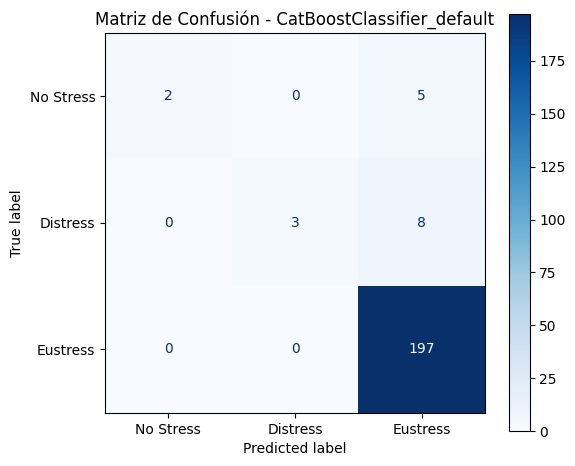


>>> Métricas del modelo: CatBoostClassifier_default
accuracy : 0.9395348837209302
precision: 0.9432779623477298
recall   : 0.9395348837209302
f1_score : 0.9234093652698305
auc_score: 0.9769251552059853
🏃 View run Default RandomForestClassifier_default_params at: https://dagshub.com/Marquinhos9873/mle3.mlflow/#/experiments/0/runs/ef162e44c16c48dda8707c3dcf947ef2
🧪 View experiment at: https://dagshub.com/Marquinhos9873/mle3.mlflow/#/experiments/0


/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/mlflow/store/tracking/rest_store.py:233: DeprecationWarning: label() is deprecated. Use is_required() or is_repeated() instead.
  req_body = message_to_json(


NameError: name 'forest_importances' is not defined

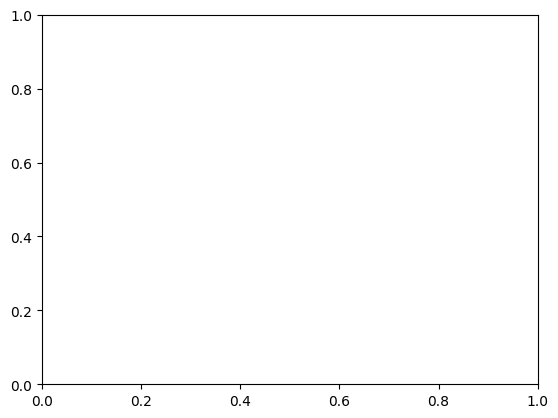

In [31]:
#CatBoostClassifier
with mlflow.start_run(run_name="Default RandomForestClassifier_default_params", nested=True):
    kitty.fit(X_train, y_train)
    predictions_kitty_default = kitty.predict(X_test)
    probabilities_kitty_default = kitty.predict_proba(X_test)
    metrics = evaluate_classification_model(
        name_model = 'CatBoostClassifier_default',
        y_real = y_test, 
        predictions = predictions_kitty_default,
        probabilities = probabilities_kitty_default,
        save_path = save_path )
    kitty_importances = kitty.get_feature_importance()
    kitty_importances = pd.Series(kitty_importances, index=X_train.columns)
    fig, ax = plt.subplots()
    forest_importances.plot.bar(ax=ax)
    ax.set_title("Feature importance")
    ax.set_ylabel("Importance ratio")
    fig.tight_layout()
    mlflow.log_figure(fig, "default_random_forest_feature_importances.png")
    mlflow.log_metrics(metrics)

#### GradesBoostingClassifier

2025/11/21 19:53:54 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 1.3.0 <= scikit-learn <= 1.6.1, but the installed version is 1.7.2. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.
2025/11/21 19:53:55 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/11/21 19:53:55 WARNING mlflow.utils.autologging_utils: MLflow statsmodels autologging is known to be compatible with 0.14.1 <= statsmodels <= 0.14.4, but the installed version is 0.14.5. If you encounter errors during autologging, try upgrading / downgrading statsmodels to a compatible version, or try upgrading MLflow.
2025/11/21 19:53:55 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/11/21 19:53:55 WARNING mlflow.utils.autologging_utils: MLflow transformers autologging is known to be compatible with 4.35.2 <= transformers <= 4.51.3, bu

      Iter       Train Loss   Remaining Time 
         1           0.2889            1.35s
         2           0.2608            1.30s
         3           0.2404            1.17s
         4           0.2200            1.15s
         5           0.2046            1.09s
         6           0.1916            1.05s
         7           0.1781            0.99s
         8           0.1664            0.94s
         9           0.1560            0.92s
        10           0.1451            0.94s
        20           0.0805            0.85s
        30           0.0491            0.76s
        40           0.0317            0.64s
        50           0.0211            0.53s
        60           0.0144            0.41s
        70           0.0102            0.30s
        80           0.0072            0.20s
        90           0.0051            0.10s


2025/11/21 19:53:57 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


       100           0.0036            0.00s


2025/11/21 19:53:57 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/mlflow/store/tracking/rest_store.py:1112: DeprecationWarning: label() is deprecated. Use is_required() or is_repeated() instead."
2025/11/21 19:53:57 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/mlflow/utils/proto_json_utils.py:121: DeprecationWarning: label() is deprecated. Use is_required() or is_repeated() instead."
2025/11/21 19:53:58 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: INTERNAL_ERROR: Response: {'error': 'unsupported endpoint, please contact support@dagshub.com'}


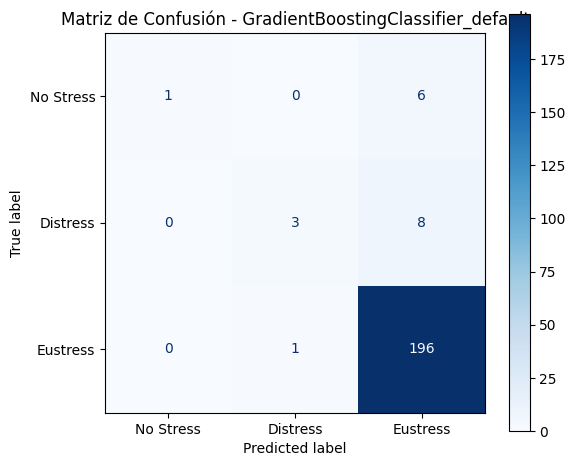


>>> Métricas del modelo: GradientBoostingClassifier_default
accuracy : 0.9302325581395349
precision: 0.926124031007752
recall   : 0.9302325581395349
f1_score : 0.9111142220444546
auc_score: 0.9430939707141558


/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/mlflow/store/tracking/rest_store.py:865: DeprecationWarning: label() is deprecated. Use is_required() or is_repeated() instead.
  req_body = message_to_json(
/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/mlflow/utils/proto_json_utils.py:121: DeprecationWarning: label() is deprecated. Use is_required() or is_repeated() instead.
  json_dict_with_int64_fields_only = _mark_int64_fields(message)


🏃 View run Default GradientBoostingClassifier_default_params at: https://dagshub.com/Marquinhos9873/mle3.mlflow/#/experiments/0/runs/c17cc8c95c3b4ee199235ce726e76c74
🧪 View experiment at: https://dagshub.com/Marquinhos9873/mle3.mlflow/#/experiments/0


In [32]:
#GradientBoostClassifier

mlflow.autolog(log_models= True)
with mlflow.start_run(run_name="Default GradientBoostingClassifier_default_params", nested=True):
    Grades.fit(X_train, y_train)
    predictions_grades_default = Grades.predict(X_test)
    probabilities_grades_default = Grades.predict_proba(X_test)
    metrics = evaluate_classification_model(
        name_model = 'GradientBoostingClassifier_default',
        y_real = y_test,
        predictions = predictions_grades_default,
        probabilities = probabilities_grades_default,
        save_path = save_path )
    mlflow.log_metrics(metrics)


2025/11/22 02:16:41 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 1.3.0 <= scikit-learn <= 1.6.1, but the installed version is 1.7.2. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.
2025/11/22 02:16:42 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/11/22 02:16:42 WARNING mlflow.utils.autologging_utils: MLflow statsmodels autologging is known to be compatible with 0.14.1 <= statsmodels <= 0.14.4, but the installed version is 0.14.5. If you encounter errors during autologging, try upgrading / downgrading statsmodels to a compatible version, or try upgrading MLflow.
2025/11/22 02:16:42 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/11/22 02:16:42 WARNING mlflow.utils.autologging_utils: MLflow transformers autologging is known to be compatible with 4.35.2 <= transformers <= 4.51.3, bu

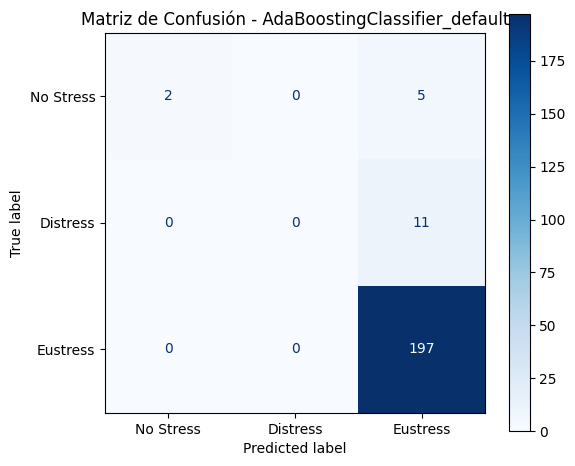

/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



>>> Métricas del modelo: AdaBoostingClassifier_default
accuracy : 0.9255813953488372
precision: 0.8800087345780108
recall   : 0.9255813953488372
f1_score : 0.8949921220142434
auc_score: 0.8615563876089407


/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/mlflow/store/tracking/rest_store.py:865: DeprecationWarning: label() is deprecated. Use is_required() or is_repeated() instead.
  req_body = message_to_json(
/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/mlflow/utils/proto_json_utils.py:121: DeprecationWarning: label() is deprecated. Use is_required() or is_repeated() instead.
  json_dict_with_int64_fields_only = _mark_int64_fields(message)


🏃 View run Default AdaBoostingClassifier_default_params at: https://dagshub.com/Marquinhos9873/mle3.mlflow/#/experiments/0/runs/b31e09d2637c4e5d970007d42338963e
🧪 View experiment at: https://dagshub.com/Marquinhos9873/mle3.mlflow/#/experiments/0


2025/11/22 02:18:30 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/mlflow/store/tracking/rest_store.py:865: DeprecationWarning: label() is deprecated. Use is_required() or is_repeated() instead."
2025/11/22 02:18:30 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/mlflow/store/tracking/rest_store.py:865: DeprecationWarning: label() is deprecated. Use is_required() or is_repeated() instead."
2025/11/22 02:18:30 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/mlflow/store/tracking/rest_store.py:1112: DeprecationWarning: label() is deprecated. Use is_required() or is_repeated() instead."
2025/11/22 02:18:30 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/marcoloq/mle2/.venv/lib/pytho

In [29]:
#AdaBoostClassifier
mlflow.autolog(log_models= True)
with mlflow.start_run(run_name="Default AdaBoostingClassifier_default_params"):
    Ada.fit(X_train, y_train)
    predictions_ada_default = Ada.predict(X_test)
    probabilities_ada_default = Ada.predict_proba(X_test)
    metrics = evaluate_classification_model(
        name_model = 'AdaBoostingClassifier_default',
        y_real = y_test,
        predictions = predictions_ada_default,
        probabilities = probabilities_ada_default,
        save_path = save_path )
    mlflow.log_metrics(metrics)

2025/11/22 02:22:43 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 1.3.0 <= scikit-learn <= 1.6.1, but the installed version is 1.7.2. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.
2025/11/22 02:22:43 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/11/22 02:22:43 WARNING mlflow.utils.autologging_utils: MLflow statsmodels autologging is known to be compatible with 0.14.1 <= statsmodels <= 0.14.4, but the installed version is 0.14.5. If you encounter errors during autologging, try upgrading / downgrading statsmodels to a compatible version, or try upgrading MLflow.
2025/11/22 02:22:43 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/11/22 02:22:43 WARNING mlflow.utils.autologging_utils: MLflow xgboost autologging is known to be compatible with 1.7.6 <= xgboost <= 3.0.1, but the instal

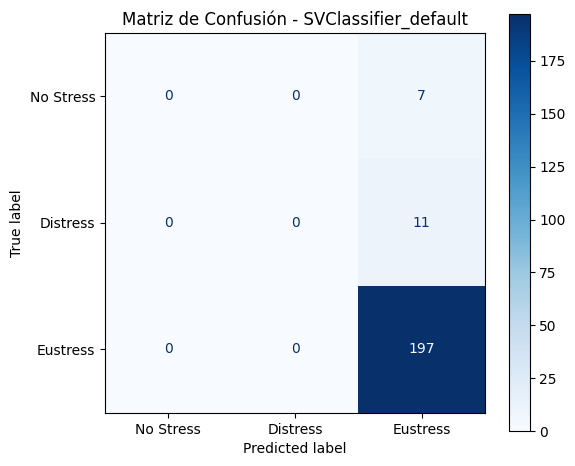

/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



>>> Métricas del modelo: SVClassifier_default
accuracy : 0.9162790697674419
precision: 0.8395673336938887
recall   : 0.9162790697674419
f1_score : 0.8762474599232333
auc_score: 0.9841777576735774


/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/mlflow/store/tracking/rest_store.py:865: DeprecationWarning: label() is deprecated. Use is_required() or is_repeated() instead.
  req_body = message_to_json(
/home/marcoloq/mle2/.venv/lib/python3.12/site-packages/mlflow/utils/proto_json_utils.py:121: DeprecationWarning: label() is deprecated. Use is_required() or is_repeated() instead.
  json_dict_with_int64_fields_only = _mark_int64_fields(message)


🏃 View run Default SVC_default_params at: https://dagshub.com/Marquinhos9873/mle3.mlflow/#/experiments/0/runs/759fe8199f014e73884becd94f8e7ae9
🧪 View experiment at: https://dagshub.com/Marquinhos9873/mle3.mlflow/#/experiments/0


In [32]:
#SVC

mlflow.autolog(log_models= True)
with mlflow.start_run(run_name="Default SVC_default_params"):
    machine.fit(X_train, y_train)
    predictions_svc_default = machine.predict(X_test)
    probabilities_svc_default = machine.predict_proba(X_test)
    metrics = evaluate_classification_model(
        name_model = 'SVClassifier_default',
        y_real = y_test,
        predictions = predictions_svc_default,
        probabilities = probabilities_svc_default,
        save_path = save_path )
    mlflow.log_metrics(metrics)

### A

### Hp ops

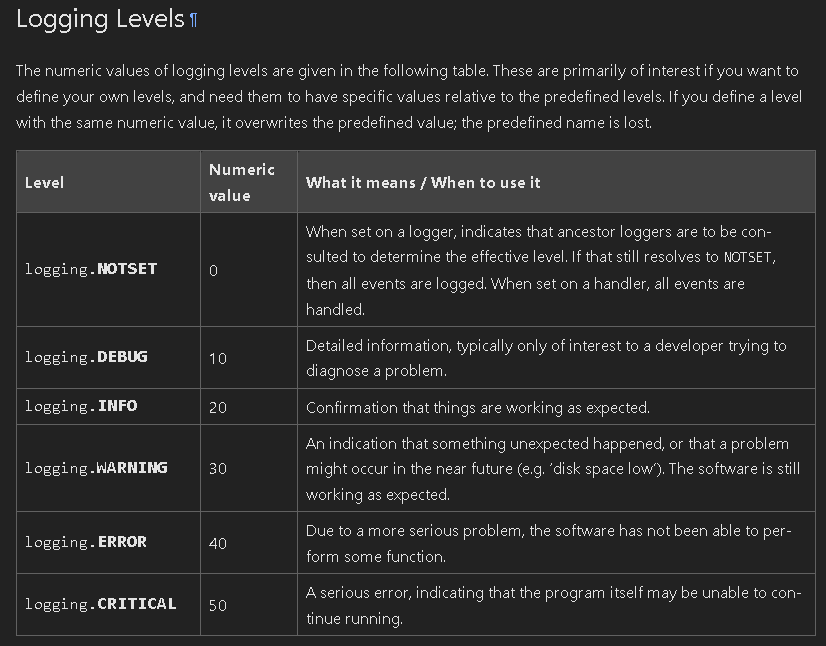